In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import warnings
warnings.filterwarnings("ignore")


d:\Anconda\envs\Paddle_tutorial\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
features = pd.read_csv("./dataset/temps.csv")
features.head()

,year,month,day,week,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend
0,2016,1,1,Fri,45,45,45.6,45,43,50,44,29
1,2016,1,2,Sat,44,45,45.7,44,41,50,44,61
2,2016,1,3,Sun,45,44,45.8,41,43,46,47,56
3,2016,1,4,Mon,44,41,45.9,40,44,48,46,53
4,2016,1,5,Tues,41,40,46.0,44,46,46,46,41


In [3]:
print('数据维度：',features.shape)

数据维度： (348, 12)


In [4]:
#处理时间数据
import datetime

#分别得到年，月，日
years = features['year']
months = features['month']
days = features['day']

#datatime格式
dates = [str(int(year))+'-'+str(int(month))+'-'+str(int(day)) for year,month,day in zip(years,months,days)]
dates = [datetime.datetime.strptime(date,'%Y-%m-%d') for date in dates]

In [5]:
dates[:5]

[datetime.datetime(2016, 1, 1, 0, 0),
 datetime.datetime(2016, 1, 2, 0, 0),
 datetime.datetime(2016, 1, 3, 0, 0),
 datetime.datetime(2016, 1, 4, 0, 0),
 datetime.datetime(2016, 1, 5, 0, 0)]

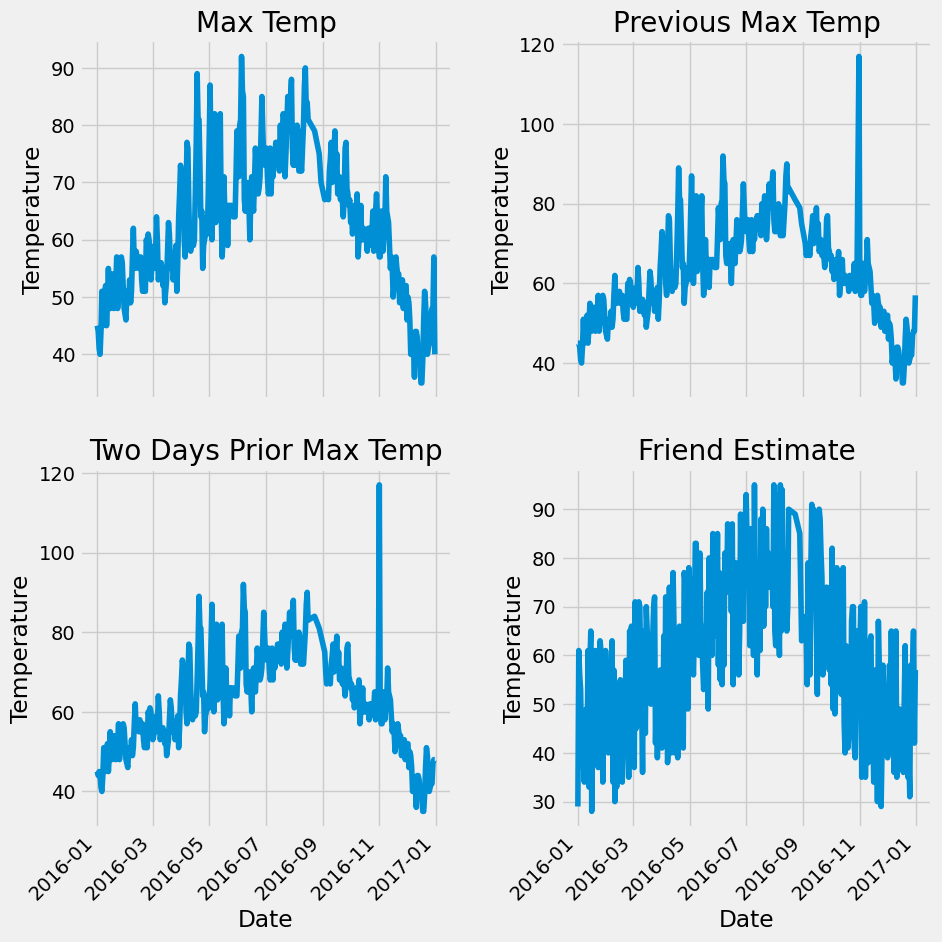

In [6]:
#指定默认风格
plt.style.use('fivethirtyeight')

#设置布局
fig,((ax1,ax2),(ax3,ax4)) = plt.subplots(nrows=2,ncols=2,figsize=(10,10))
fig.autofmt_xdate(rotation=45)

#标签值
ax1.plot(dates,features['actual'])
ax1.set_xlabel('');ax1.set_ylabel('Temperature');ax1.set_title('Max Temp')

#昨天
ax2.plot(dates,features['temp_1'])
ax2.set_xlabel('');ax2.set_ylabel('Temperature');ax2.set_title('Previous Max Temp')

#前天
ax3.plot(dates,features['temp_2'])
ax3.set_xlabel('Date');ax3.set_ylabel('Temperature');ax3.set_title('Two Days Prior Max Temp')

#朋友
ax4.plot(dates,features['friend'])
ax4.set_xlabel('Date');ax4.set_ylabel('Temperature');ax4.set_title('Friend Estimate')

plt.tight_layout(pad = 2)

In [7]:
#独热编码
features = pd.get_dummies(features)#独热编码，可以进行主动查找哪个是字符串并且赋予其独热编码
features.head(5)

,year,month,day,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend,week_Fri,week_Mon,week_Sat,week_Sun,week_Thurs,week_Tues,week_Wed
0,2016,1,1,45,45,45.6,45,43,50,44,29,1,0,0,0,0,0,0
1,2016,1,2,44,45,45.7,44,41,50,44,61,0,0,1,0,0,0,0
2,2016,1,3,45,44,45.8,41,43,46,47,56,0,0,0,1,0,0,0
3,2016,1,4,44,41,45.9,40,44,48,46,53,0,1,0,0,0,0,0
4,2016,1,5,41,40,46.0,44,46,46,46,41,0,0,0,0,0,1,0


In [8]:
# 标签
labels = np.array(features['actual'])

#在特征中去掉标签
features = features.drop('actual',axis = 1)
features = features.drop('forecast_noaa',axis = 1)
features = features.drop('forecast_acc',axis = 1)
features = features.drop('forecast_under',axis = 1)
#名字单独保存一下，以备后患
feature_list = list(features.columns)

#转换成合适的格式
features = np.array(features)


In [9]:
features.shape

(348, 14)

In [10]:
from sklearn import preprocessing
input_features = preprocessing.StandardScaler().fit_transform(features)#初始化

In [11]:
input_features[0]

array([ 0.        , -1.5678393 , -1.65682171, -1.45311448, -1.46252836,
       -1.3470703 , -1.98891668,  2.44131112, -0.40482045, -0.40961596,
       -0.40482045, -0.40482045, -0.41913682, -0.40482045])

In [16]:
len(input_features)

348

### 构建网络模型

In [15]:
x = torch.tensor(input_features, dtype=float)

y = torch.tensor(labels, dtype = float)

#权重参数初始化
weights = torch.randn((14,128), dtype = float ,requires_grad = True) # 特征参数[348,14]*[14,128]
biases = torch.randn(128,dtype = float, requires_grad= True) # 偏置参数要对128个特征都要有偏置
weights2 = torch.randn((128,1),dtype = float, requires_grad= True)# 将128个特征转化成1个参数
biases2 = torch.randn(1,dtype = float, requires_grad= True)# 对最后结果进行微调

learning_rate = 0.001
losses = []

for i in range(1000):
    #计算隐层
    hidden = x.mm(weights)+biases
    #加入激活函数
    hidden = torch.relu(hidden)
    #预测结果
    predictions = hidden.mm(weights2) + biases2
    #通计算损失
    loss = torch.mean((predictions - y)**2)
    losses.append(loss.data.numpy())

    #打印损失值
    if i % 100 == 0:
        print('loss:',loss)
    #反向传播计算
    loss.backward()

    #更新参数
    weights.data.add_(- learning_rate*weights.grad.data)
    biases.data.add_(- learning_rate*biases.grad.data)
    weights2.data.add_(- learning_rate*weights2.grad.data)
    biases2.data.add_(- learning_rate*biases2.grad.data)
   
   #每次迭代都记得要清空
    weights.grad.data.zero_()
    biases.grad.data.zero_()
    weights.grad.data.zero_()
    biases2.grad.data.zero_()
    


loss: tensor(4103.0456, dtype=torch.float64, grad_fn=<MeanBackward0>)
loss: tensor(177.4779, dtype=torch.float64, grad_fn=<MeanBackward0>)
loss: tensor(154.5742, dtype=torch.float64, grad_fn=<MeanBackward0>)
loss: tensor(147.3164, dtype=torch.float64, grad_fn=<MeanBackward0>)
loss: tensor(nan, dtype=torch.float64, grad_fn=<MeanBackward0>)
loss: tensor(nan, dtype=torch.float64, grad_fn=<MeanBackward0>)
loss: tensor(nan, dtype=torch.float64, grad_fn=<MeanBackward0>)
loss: tensor(nan, dtype=torch.float64, grad_fn=<MeanBackward0>)
loss: tensor(nan, dtype=torch.float64, grad_fn=<MeanBackward0>)
loss: tensor(nan, dtype=torch.float64, grad_fn=<MeanBackward0>)


### 更简单的构建网络模型

In [18]:
input_size = input_features.shape[1]
hidden_size = 128
output_size = 1
batch_size = 16
my_nn = torch.nn.Sequential(
    torch.nn.Linear(input_size, hidden_size),
    torch.nn.Sigmoid(),
    torch.nn.Linear(hidden_size, output_size)


)

cost = torch.nn.MSELoss(reduction='mean')
optimizer = torch.optim.Adam(my_nn.parameters(),lr = 0.001)



In [19]:
#训练网络
losses = []

for i in range(1000):
    batch_loss = []
    #MINI-Batch方法来进行训练
    for start in range(0, len(input_features),batch_size):
        end  =start + batch_size if start + batch_size <len(input_features) else len(input_features)
        xx = torch.tensor(input_features[start:end], dtype= torch.float, requires_grad= True)
        yy = torch.tensor(labels[start:end], dtype= torch.float, requires_grad=True)
        predictions = my_nn(xx)
        loss = cost(predictions,yy)
        optimizer.zero_grad()
        loss.backward(retain_graph=True)#如果需要重复执行的话
        optimizer.step()
        batch_loss.append(loss.data.numpy())
    
    if i % 100 == 0:
        losses.append(np.mean(batch_loss))
        print(i , np.mean(batch_loss))
        

0 3928.8584
100 37.87187
200 35.59857
300 35.28067
400 35.10922
500 34.96761
600 34.841278
700 34.71895
800 34.59482
900 34.466854


In [22]:
x = torch.tensor(input_features, dtype = torch.float)
predict = my_nn(x).data.numpy()

In [24]:
dates = [str(int(year))+'-'+str(int(month))+'-'+str(int(day)) for year,month,day in zip(years,months,days)]
dates = [datetime.datetime.strptime(date,'%Y-%m-%d') for date in dates]

true_data = pd.DataFrame(data = {'data':dates, 'actual' : labels})

years = features[:, feature_list.index('year')]
months = features[:, feature_list.index('month')]
days = features[:, feature_list.index('day')]


test_dates = [str(int(year))+'-'+str(int(month))+'-'+str(int(day)) for year,month,day in zip(years,months,days)]
test_dates = [datetime.datetime.strptime(date,'%Y-%m-%d') for date in test_dates]

predictions_data =  pd.DataFrame(data = {'data':test_dates, 'prediction' : predict.reshape(-1)})##predict要是一列的格式，不能是一个矩阵

Text(0.5, 1.0, 'Actual and Predicted Values')

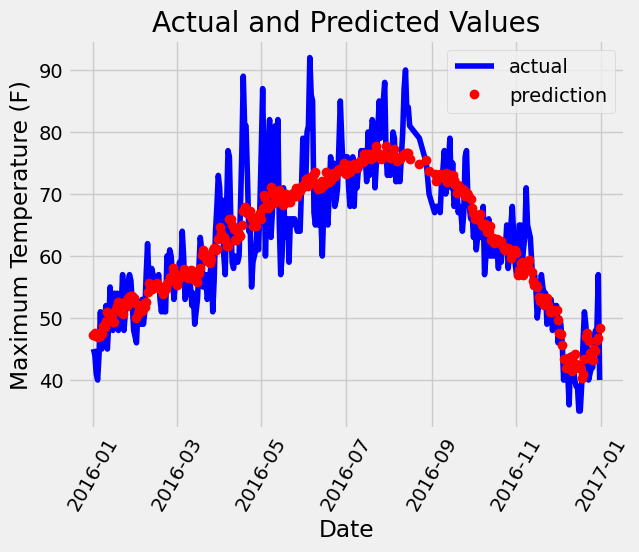

In [26]:
# 真实值
plt.plot(true_data['data'], true_data['actual'], 'b-',label = 'actual')


plt.plot(predictions_data['data'],predictions_data['prediction'],'ro',label = 'prediction')
plt.xticks(rotation = '60')
plt.legend()

plt.xlabel('Date'); plt.ylabel('Maximum Temperature (F)'); plt.title('Actual and Predicted Values')